In [56]:
#Karthick N 
#24BAD055
#import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
#Load the dataset
df = pd.read_csv("diabetes_bagging.csv")
print(df.head())
df.shape

   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1


(120, 6)

In [58]:
#Split Features & Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,stratify=y
)

In [59]:
#Train Decision Tree
dt = DecisionTreeClassifier(max_depth=2,random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9722222222222222


In [60]:
#Apply Bagging
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    max_samples=0.8,
    random_state=42
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

bag_accuracy = accuracy_score(y_test, y_pred_bag)
print("Bagging Accuracy:", bag_accuracy)

Bagging Accuracy: 0.9722222222222222


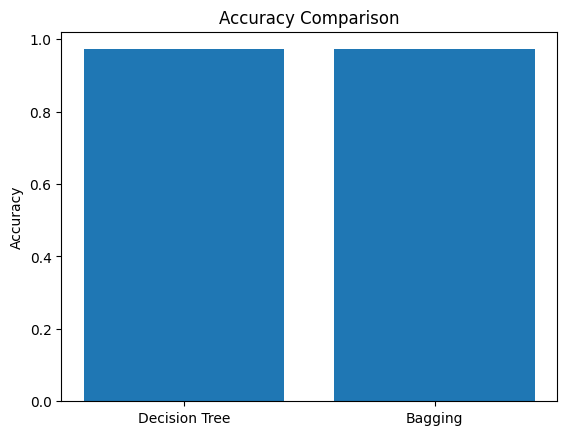

In [61]:
#Accuracy Comparison Graph
models = ["Decision Tree", "Bagging"]
accuracies = [dt_accuracy, bag_accuracy]

plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

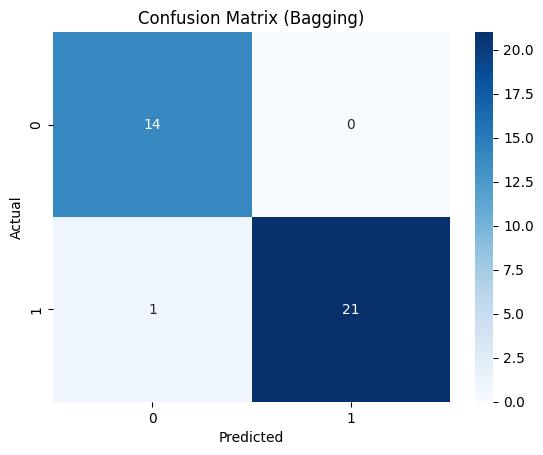

In [62]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_bag)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Bagging)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()